![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Final Project - Design

#### By: Sergi Nàcher Muñoz

## 0. Imports 

### 0.1. General libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength

### 0.2. Materials

In [4]:
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## Part I. Design and Simulation of Individual Components 

## 1. Simulating Propagation Modes in SOI Waveguides

### 1.1. Define the SOI waveguide structure (450 nm width, 220 nm thickness). 

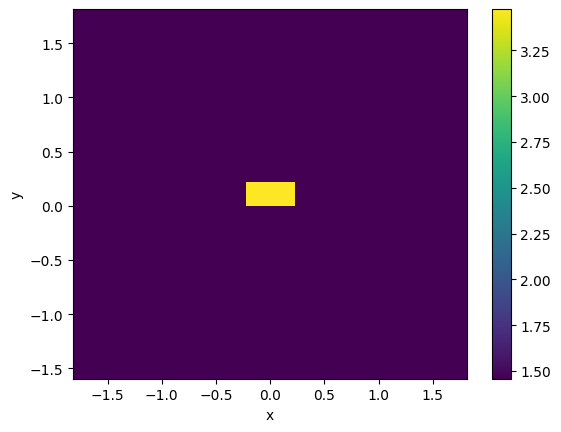

In [5]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = 1550 * nm, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)

deep_waveguide.plot_index()

### 1.2. Simulate fundamental TE and TM modes. 

In [6]:
deep_waveguide.n_eff

2026-03-23 16:10:01.367 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache\Waveguide_198a1ab0a96c4a6f.npz.


array([2.33508782+7.05715980e-05j, 1.7447082 +2.39341986e-04j,
       1.46251286+2.05632472e-04j, 1.43196857+2.18207211e-04j])

In [7]:
deep_waveguide.fraction_te

array([0.960726  , 0.06940437, 0.64309704, 0.99810644])

In [8]:
deep_waveguide.fraction_tm

array([0.039274  , 0.93059563, 0.35690296, 0.00189356])

Text(0.5, 1.0, 'Modo 0 - Campo Ex (Modo TE0)')

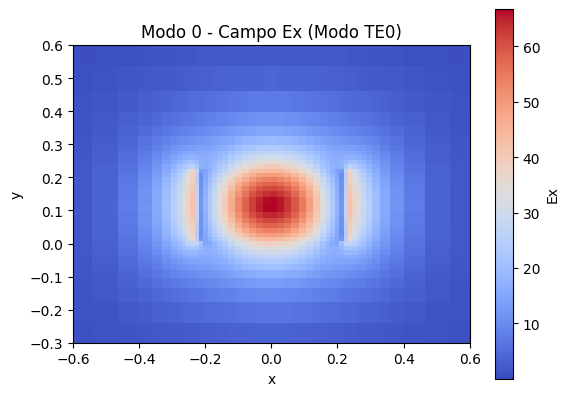

In [9]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 0 - Campo Ex (Modo TE0)')

Text(0.5, 1.0, 'Modo 1 - Campo Ey (Modo TM0)')

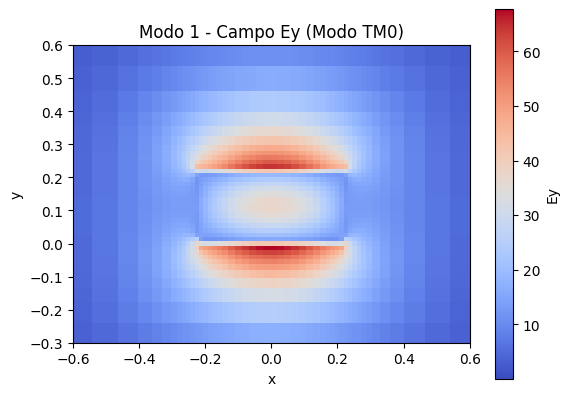

In [10]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 1 - Campo Ey (Modo TM0)')

Para el modo fundamental TM0 se puede observar un campo poco confinado en el núcleo, y en su lugar la luz viaja por el cladding.

Ya tenemos los modos fundamentales tanto para TE como para TM. Ahora vamos a verificar que los demás modos están en corte

Text(0.5, 1.0, 'Modo 2 - Campo Ex')

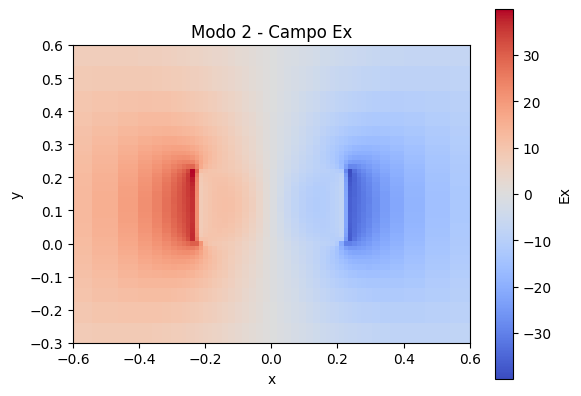

In [11]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ex')

Text(0.5, 1.0, 'Modo 2 - Campo Ey')

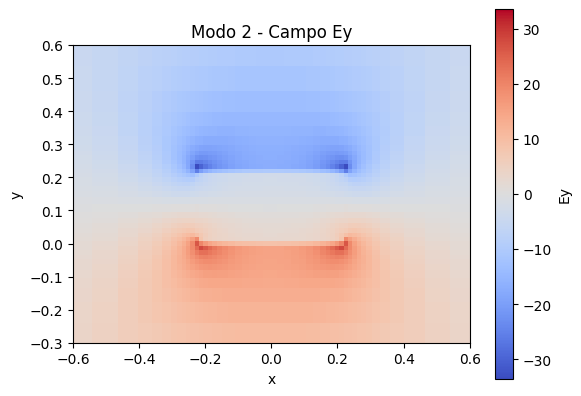

In [12]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-0.6, 0.6), # Set the x and y limits
                          ylim=(-0.3, 0.6)
) 

plt.title('Modo 2 - Campo Ey')

Por tanto, hemos verificado que los siguientes modos estarán en corte como ya se había previsto.

### 1.3. Extract effective index (n_eff) and group index (n_g) values. 

In [13]:
# Índice efectivo TE0 y TM0

n_eff_TE = deep_waveguide.n_eff.real[0]
n_eff_TM = deep_waveguide.n_eff.real[1]
print(f"Índice efectivo del modo TE0: {n_eff_TE:.4f}")
print(f"Índice efectivo del modo TM0: {n_eff_TM:.4f}")

Índice efectivo del modo TE0: 2.3351
Índice efectivo del modo TM0: 1.7447


In [14]:
'''
wavelengths = np.linspace(1.5,1.6,11)
lambda_0 = 1.55

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width = 0.45, # Waveguide width
    core_thickness = 0.22, # Waveguide height 
    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = wavelengths, # Wavelength to simulate
    num_modes = 4, # Targeted number of modes to find 
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20, # Parameters of the grid
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double'
)


lista = [n_eff_TE, n_eff_TM]

# Centramos la longitud de onda

X = wavelengths - lambda_0

# Ajuste polinómico de grado 2

s = 0

for i in lista:

    coeffs = np.polyfit(X, i, 2)   # polyfit devuelve [coef_cuadratico, coef_lineal, termino_indep]

    n3 = coeffs[0]  # Término cuadrático
    n2 = coeffs[1]  # Término lineal
    n1 = coeffs[2]  # Término independiente

    # Cálculo de n_g y D
    n_g = n1 - n2 * lambda_0
    c = 3e8
    D = -(2 * lambda_0 * n3) / c
    n_eff =  n1 + n2 * (X) + n3 * (X)**2
    

    if s == 0:
        print('Para la guía de onda deep y modo TE: \n'
        f'n1 = {n1:.4f}, n2 = {n2:.4f}, n3 = {n3:.4f}, n_g = {n_g:.4f}, D = {D} \n')
        plt.plot(wavelengths,n_eff, '-o', label ='n_eff_TE_deep')

    elif s == 1: 
        print('Para la guía de onda deep y modo TM: \n'
        f'n1 = {n1:.4f}, n2 = {n2:.4f}, n3 = {n3:.4f}, n_g = {n_g:.4f}, D = {D} \n')
        plt.plot(wavelengths,n_eff, '-o', label ='n_eff_TM_deep')

        # Configuración final del gráfico
        plt.xlabel("Wavelength ($\mu m$)")
        plt.ylabel("Effective index ($n_{eff}$)")
        plt.title("Ajuste polinómico de modos (Guía deep)")
        plt.grid()
        plt.legend() 
        plt.show()

    s += 1

'''

<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:59: SyntaxWarning: invalid escape sequence '\m'
C:\Users\cfp\AppData\Local\Temp\ipykernel_15236\2040231127.py:59: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Wavelength ($\mu m$)")


'\nwavelengths = np.linspace(1.5,1.6,11)\nlambda_0 = 1.55\n\ndeep_waveguide = gt.modes.Waveguide(\n    # Geometrical Parameters\n    core_width = 0.45, # Waveguide width\n    core_thickness = 0.22, # Waveguide height \n    slab_thickness = 0,  # For shallow waveguides - Set to 0 if its a deep-etched waveguide.\n    # Materials\n    core_material = \'si\', #  Material of the waveguide\n    clad_material = \'sio2\', # Surrounding material\n    # Modesolver Parameters\n    wavelength = wavelengths, # Wavelength to simulate\n    num_modes = 4, # Targeted number of modes to find \n    max_grid_scaling = 1.5, # Parameters of the grid\n    grid_resolution = 20, # Parameters of the grid\n    cache_path = \'.cache/\', # Important! In order to save simulation time, set your cache Path!\n    precision = \'double\'\n)\n\n\nlista = [n_eff_TE, n_eff_TM]\n\n# Centramos la longitud de onda\n\nX = wavelengths - lambda_0\n\n# Ajuste polinómico de grado 2\n\ns = 0\n\nfor i in lista:\n\n    coeffs = np.po

## 2. Designing Directional Couplers

### 2.1. Simulate directional couplers in GDSFactory. 

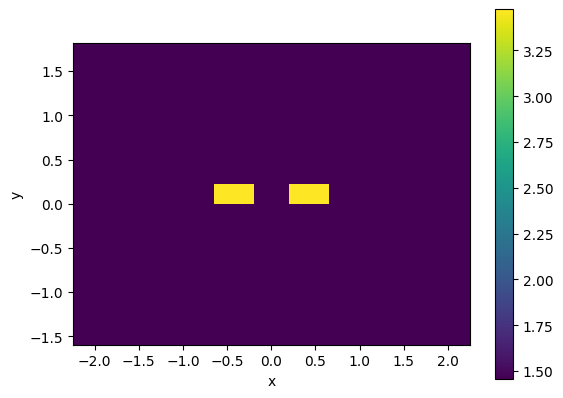

In [56]:
lambda_c = 1.55

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width = (0.45, 0.45), # Waveguide width
    slab_thickness = 0, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness = 0.22, # Waveguide height 
    gap = 0.4,
    # Materials
    core_material = 'si', #  Material of the waveguide
    clad_material = 'sio2', # Surrounding material
    # Modesolver Parameters
    wavelength = lambda_c, # Wavelength to simulate
    num_modes = 6, # Number of modes to find
    cache_path = '.cache/', # Important! In order to save simulation time, set your cache Path!
    precision = 'double',
    max_grid_scaling = 1.5, # Parameters of the grid
    grid_resolution = 20 # Parameters of the grid
)

dcoupler_cs.plot_index()

### 2.2. Sweep different gap values and coupling lengths. 

In [59]:
dcoupler_neff = dcoupler_cs.n_eff
print(dcoupler_neff)

c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
c:\Users\cfp\Desktop\Diseño_S\Repositories_diseño\pic-upv-lab5-finalproject\.venv\Lib\site-packages\tidy3d\components\mode\derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
c:\Users\cfp\

16:50:55 Hora estándar romance WARNING: Mode field at frequency index 0, mode   
                               index 5 does not decay at the plane boundaries.  

2026-03-23 16:50:55.224 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache\WaveguideCoupler_ffe9090b758fa39f.npz.
[2.35816142+6.53289443e-05j 2.33459217+7.01480984e-05j
 1.77349409+2.32176528e-04j 1.72117362+2.47894303e-04j
 1.47655318+2.00030999e-04j 1.4489136 +2.10230439e-04j]


In [60]:
dcoupler_cs.fraction_te

array([0.96692074, 0.96082553, 0.06235488, 0.07784008, 0.74575472,
       0.38924343])

In [61]:
dcoupler_cs.fraction_tm

array([0.03307926, 0.03917447, 0.93764512, 0.92215992, 0.25424528,
       0.61075657])

#### Plots

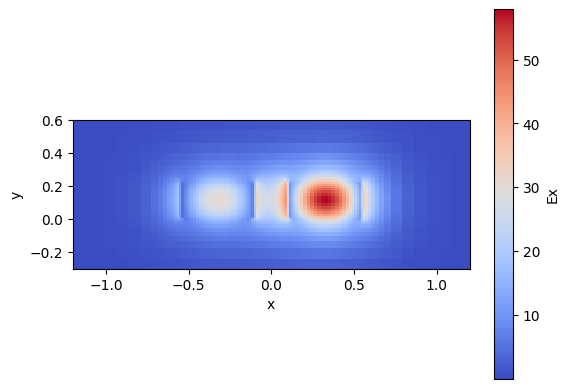

In [44]:
dcoupler_cs.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

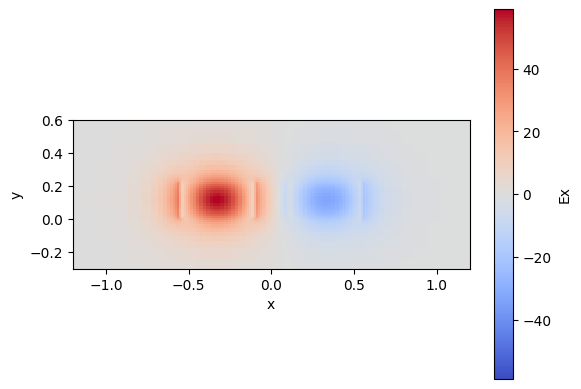

In [45]:
dcoupler_cs.plot_field(mode_index=1, # Mode to be plotted
                          field_name='Ex',  # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

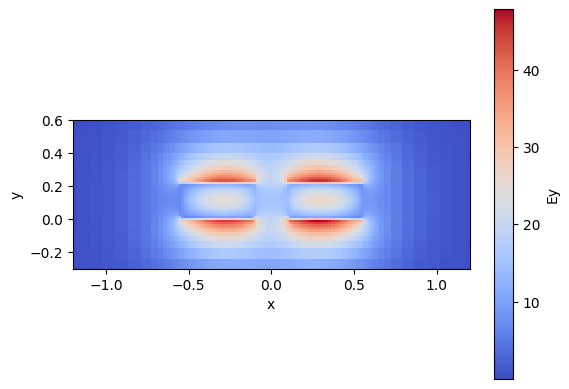

In [46]:
dcoupler_cs.plot_field(mode_index=2, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

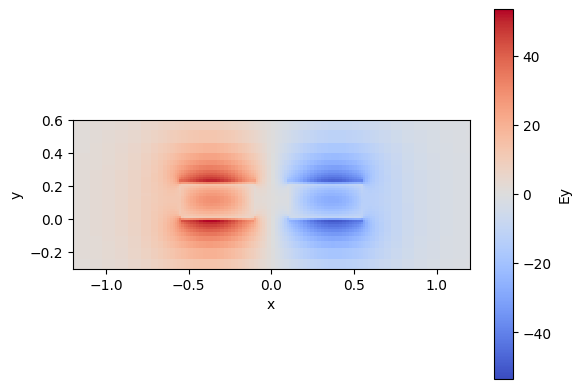

In [47]:
dcoupler_cs.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.2, 1.2), # Set the x and y limits
                          ylim=(-0.3, 0.6)
)

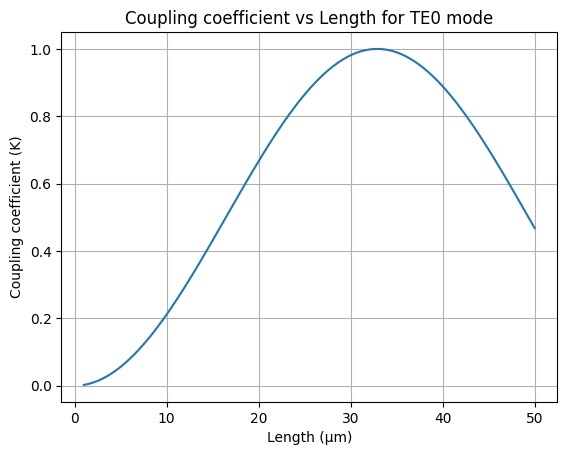

In [67]:
length_values = np.linspace(1,50,200)
dcoupler_cs.gap = 0.4

L_pi_TE0 = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
L_pi_TM0 = 0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)

K_values = []

for length in length_values:
    K = np.sin(1/2 * np.pi * (length/L_pi_TE0))**2
    K_values.append(K)

plt.plot(length_values, K_values)
plt.xlabel("Length (µm)")
plt.ylabel("Coupling coefficient (K)")
plt.title("Coupling coefficient vs Length for TE0 mode")
plt.grid()
plt.show()

In [68]:
K_targets = [0.05, 0.17, 0.23, 0.3, 0.5]

print("Lengths for different K values:")
for K_target in K_targets:
    length_target = (L_pi_TE0 * 2 / np.pi) * np.arcsin(np.sqrt(K_target))
    print(f"Length for K={K_target}: {length_target:.2f} µm")

Lengths for different K values:
Length for K=0.05: 4.72 µm
Length for K=0.17: 8.90 µm
Length for K=0.23: 10.47 µm
Length for K=0.3: 12.13 µm
Length for K=0.5: 16.44 µm
